In [1]:
# Data Loading, Cleaning and Feature Engineering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
 # Load Dataset
data = pd.read_csv('winequality-red.csv')

# Display first five rows
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,NaN,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,NaN,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,NaN,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Dataset Information
print("Dataset Shape :", data.shape)
print("\nColumn Names")
print(data.columns)
print("\nDataset Information")
data.info()

# Statistical Summary
data.describe()

#Missing Values
print("Missing Values")
print(data.isnull().sum())

Dataset Shape : (1599, 12)

Column Names
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1598 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1598 non-null   float64
 6   total sulfur dioxide  1598 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   f

In [5]:
# Mean Imputation

from sklearn.impute import SimpleImputer

X = data.drop('quality', axis=1)
y = data['quality']
mean_imputer = SimpleImputer(strategy='mean')
X_mean = mean_imputer.fit_transform(X)
print(pd.DataFrame(X_mean).isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
dtype: int64


In [6]:
#Duplicate record
duplicates = data.duplicated().sum()
print("Duplicate Rows =", duplicates)

Duplicate Rows = 239


In [7]:
#Remove Duplicate
data = data.drop_duplicates()
print("New Shape =", data.shape)

New Shape = (1360, 12)


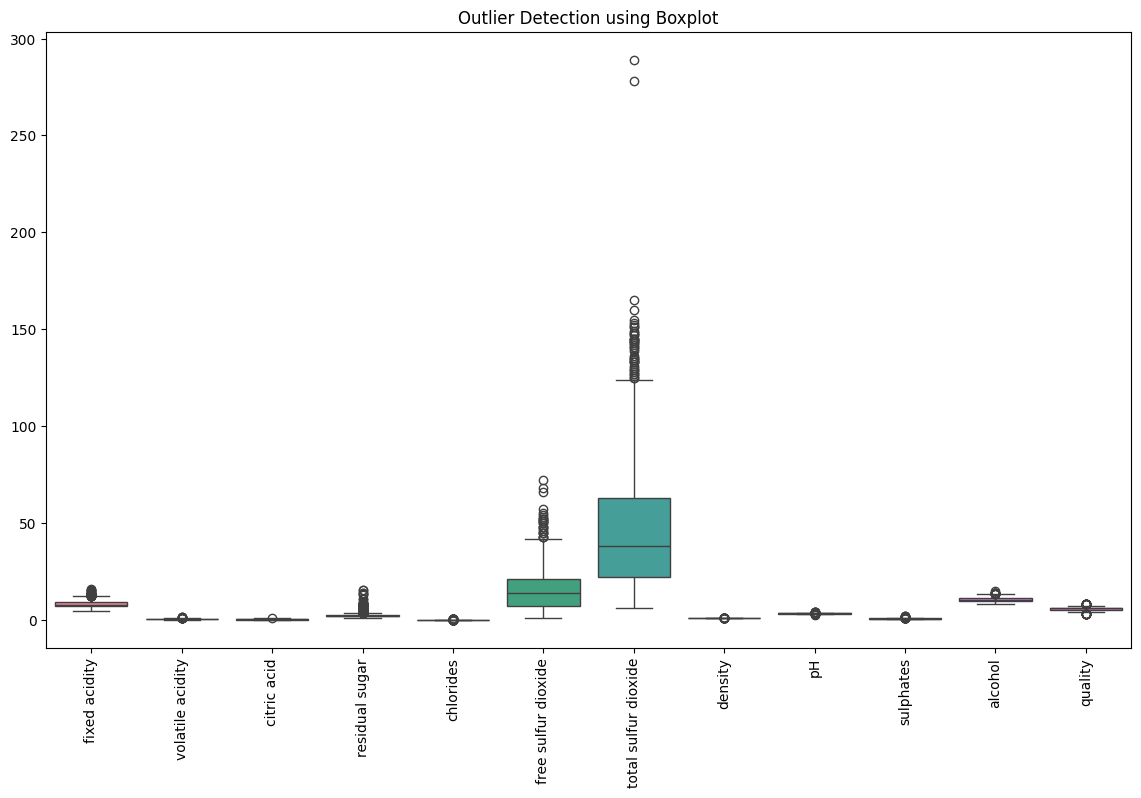

In [8]:
#Detect Outliers using Boxplot
plt.figure(figsize=(14,8))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplot")
plt.show()

In [9]:
 # Remove Outliers using IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
data_clean = data[~((data < (Q1 - 1.5*IQR)) |
                    (data > (Q3 + 1.5*IQR))).any(axis=1)]
print("Original Shape :", data.shape)
print("After Removing Outliers :", data_clean.shape)

Original Shape : (1360, 12)
After Removing Outliers : (1006, 12)
